In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [35]:
torch.manual_seed(42)

In [36]:
# check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [37]:
df = pd.read_csv("/content/sample_data/fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [38]:
df.shape

(6000, 785)

Basic Graph

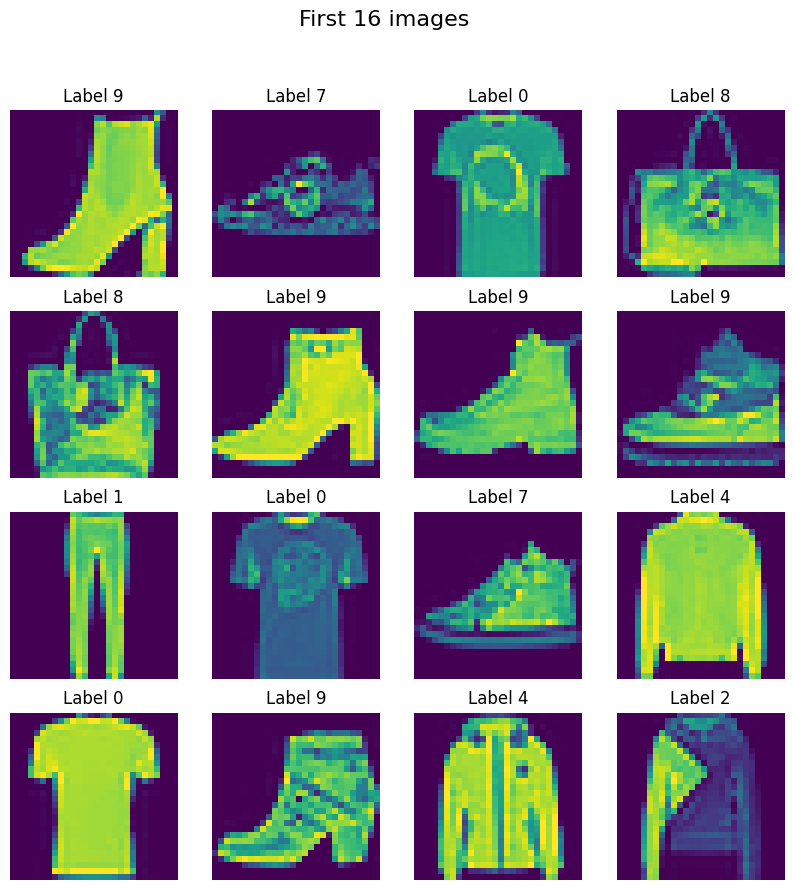

In [39]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 images", fontsize=16)

for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')

  ax.set_title(f"Label {df.iloc[i,0]}")

In [40]:
len(df.columns)

785

In [41]:
len(df.iloc[:,1:])

6000

In [42]:
df['label'].unique()

array([9, 7, 0, 8, 1, 4, 2, 6, 5, 3])

In [43]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [44]:
X

array([[  0,   0,   0, ..., 165,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
# scaling the features
X_train = X_train/255.0
X_test = X_test/255.0

### CustomDataset

In [47]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)
  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [48]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [49]:
len(train_dataset)

4800

In [50]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [51]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

### Define NN class

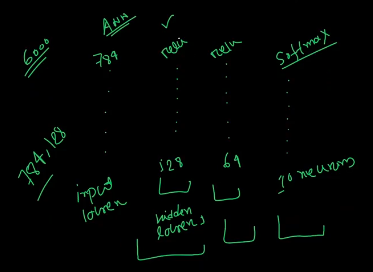

In [52]:
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
      nn.Linear(num_features, 128),
      nn.ReLU(),
      nn.Linear(128, 64),
      nn.ReLU(),
      nn.Linear(64, 10)
      # Softmax is integrated in CCE(CrossEntropyLoss) Loss function
)

  def forward(self, X):
    return self.model(X)

### Instatiate Model

In [53]:
epochs = 10
learning_rate = 0.1

In [54]:
model = MyNN(X_train.shape[1])

#for gpu
model = model.to(device)

In [55]:
# Loss function
criterion = nn.CrossEntropyLoss()

In [56]:
# Optimizers
optimizer = optim.SGD(model.parameters(), learning_rate)

In [57]:
print("Batch Number", len(train_loader))

Batch Number 150


In [58]:
len(train_loader)

150

### Training Loop

In [59]:
for epoch in range(epochs):
  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #Forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    #update
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

avg_loss = total_epoch_loss/len(train_loader)
print(avg_loss)


0.39741520086924237


### Evaluation

In [60]:
temp = torch.tensor([
                    [0.2,0.1,0.7],
                    [0.2,0.1,0.7]
                    ])

_, predicted = torch.max(temp,1) # returns max value or per row and its index as here is the max is 7 and its index is 2
print(_)
print(predicted)
print()
print(torch.max(temp,1))

tensor([0.7000, 0.7000])
tensor([2, 2])

torch.return_types.max(
values=tensor([0.7000, 0.7000]),
indices=tensor([2, 2]))


In [61]:
model.eval()
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)
    _, predicted = torch.max(outputs, 1)
    total += batch_labels.shape[0]

    correct += (predicted == batch_labels).sum().item()

accuracy = correct / total
print('Accuracy: ', accuracy)

Accuracy:  0.8325
